##BA 64061 Assignment 1: Neural Networks -- IMDB hyperparameter experiment.

In [2]:
# Imports
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [ ]:
# Load the IMDb dataset
from keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [4]:
# Prepare the data
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [5]:
# Check the shape of x_train and y_train
print(x_train.shape)
print(y_train.shape)

(25000, 10000)
(25000,)


In [6]:
# Validation split
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [7]:
# Build the models
# The two‑hidden‑layer IMDB model from class serves as the baseline.

models = []   # initialize an empty list

# 1. Baseline: two hidden layers of 16 units
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("baseline_2x16", model))

# 2. Task 1: three hidden layers
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("three_layers_3x16", model))

# 3. Task 2: more hidden units (64)
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("units_64", model))

# 4. Task 3: mse loss instead of binary_crossentropy
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="mse", metrics=["accuracy"])
models.append(("mse_loss", model))

# 5. Task 4: tanh activation instead of relu
model = keras.Sequential([
    layers.Dense(16, activation="tanh"),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("tanh_activation", model))

# 6. Task 5: dropout to improve validation performance
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("dropout_0.5", model))

# 7. Task 5: L2 regularization to improve validation performance
model = keras.Sequential([
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(16, activation="relu",
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop", loss="binary_crossentropy",
              metrics=["accuracy"])
models.append(("l2_0.001", model))

In [13]:
histories = {}
test_accs = {}
val_best = {}
for name, model in models:
    history = model.fit(partial_x_train, partial_y_train,
                        epochs=20, batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    val_acc = history.history["val_accuracy"]
    print(name, "-- val acc (final):", round(float(val_acc[-1]), 4),
          "| val acc (best):", round(float(np.max(val_acc)), 4),
          "| test loss:", round(float(test_loss), 4),
          "| test acc:", round(float(test_acc), 4))
    histories[name] = history.history
    test_accs[name] = float(test_acc)
    val_best[name] = float(np.max(val_acc))

baseline_2x16 -- val acc (final): 0.8663 | val acc (best): 0.8715 | test loss: 0.9951 | test acc: 0.8551
three_layers_3x16 -- val acc (final): 0.8661 | val acc (best): 0.8701 | test loss: 1.2249 | test acc: 0.8526
units_64 -- val acc (final): 0.8738 | val acc (best): 0.8758 | test loss: 1.0667 | test acc: 0.861
mse_loss -- val acc (final): 0.873 | val acc (best): 0.8749 | test loss: 0.1171 | test acc: 0.8594
tanh_activation -- val acc (final): 0.8637 | val acc (best): 0.8662 | test loss: 1.0457 | test acc: 0.8512
dropout_0.5 -- val acc (final): 0.8818 | val acc (best): 0.8867 | test loss: 0.8927 | test acc: 0.8726
l2_0.001 -- val acc (final): 0.8666 | val acc (best): 0.8734 | test loss: 0.5368 | test acc: 0.8594


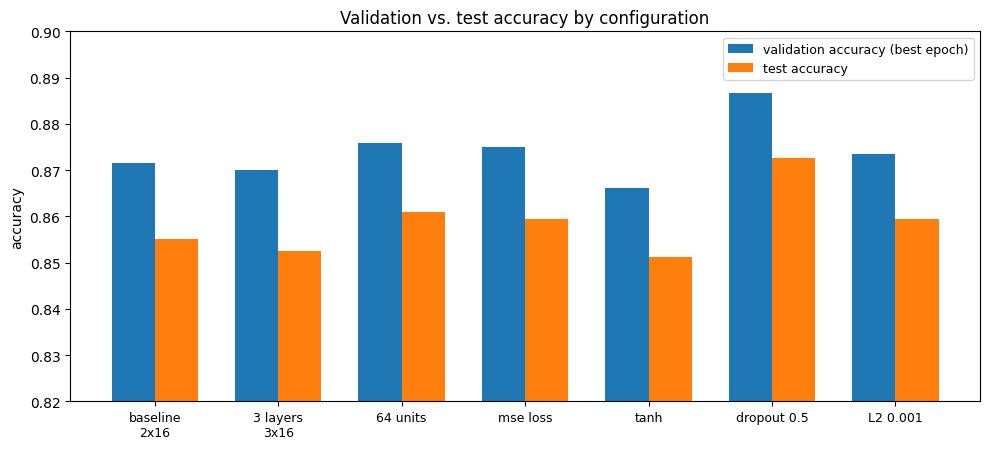

In [26]:
names = [name for name, _ in models]
labels = ["baseline\n2x16", "3 layers\n3x16", "64 units",
          "mse loss", "tanh", "dropout 0.5", "L2 0.001"]

# 1. Best validation accuracy vs. test accuracy, by configuration
x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - w / 2, [val_best[n] for n in names], w, label="validation accuracy (best epoch)")
ax.bar(x + w / 2, [test_accs[n] for n in names], w, label="test accuracy")
ax.set_xticks(x, labels, fontsize=9)
ax.set_ylabel("accuracy")
ax.set_title("Validation vs. test accuracy by configuration")
ax.legend(fontsize=9)
ax.set_ylim(0.82, 0.90)
fig.tight_layout()
plt.show()


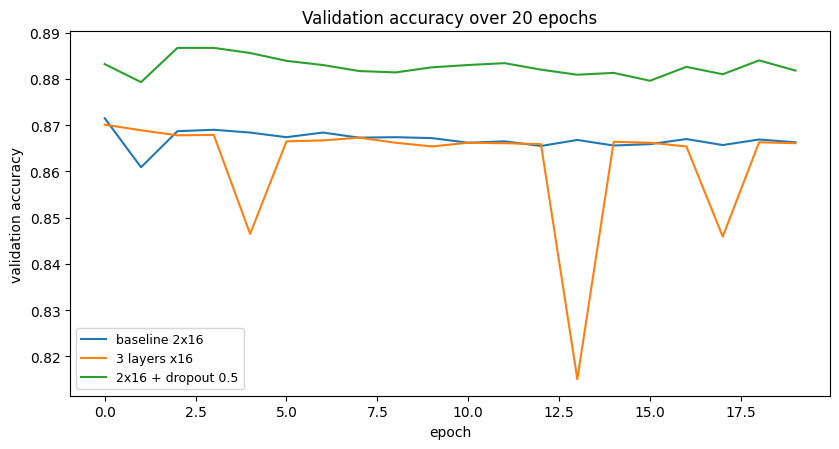

In [27]:
# 2. Validation accuracy over the 20 epochs
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name, lab in [("baseline_2x16", "baseline 2x16"),
                  ("three_layers_3x16", "3 layers x16"),
                  ("dropout_0.5", "2x16 + dropout 0.5")]:
    ax.plot(histories[name]["val_accuracy"], label=lab)
ax.set_xlabel("epoch")
ax.set_ylabel("validation accuracy")
ax.set_title("Validation accuracy over 20 epochs")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

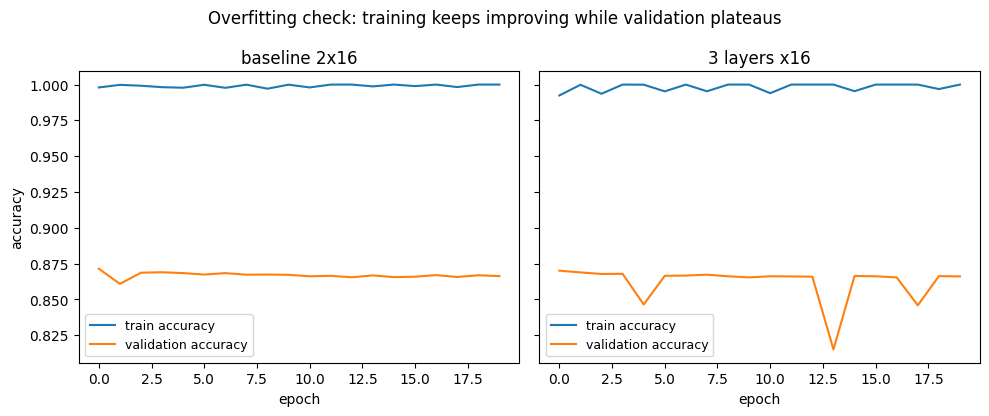

In [28]:
# 3. Overfitting check - graph
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, name, title in [(axes[0], "baseline_2x16", "baseline 2x16"),
                        (axes[1], "three_layers_3x16", "3 layers x16")]:
    ax.plot(histories[name]["accuracy"], label="train accuracy")
    ax.plot(histories[name]["val_accuracy"], label="validation accuracy")
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.legend(fontsize=9)
axes[0].set_ylabel("accuracy")
fig.suptitle("Overfitting check: training keeps improving while validation plateaus")
fig.tight_layout()
plt.show()